# M2608.001300 기계학습 기초<br> Assignment 2: Support Vector Machines

## Setup
Check that Python 3.5 or later is installed (although Python 2.x may work, it is deprecated so we strongly recommend you use Python 3 instead), as well as Scikit-Learn 0.20 or later is installed.

In [1]:
!pip install qpsolvers osqp

In [2]:
!pip install scikit-learn matplotlib

In [3]:
# Python >=3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn >=0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

# Common imports
import numpy as np
import os
from typing import Tuple

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

## Problem 1. Dataset load & Plot

실행만 시키면 됩니다.

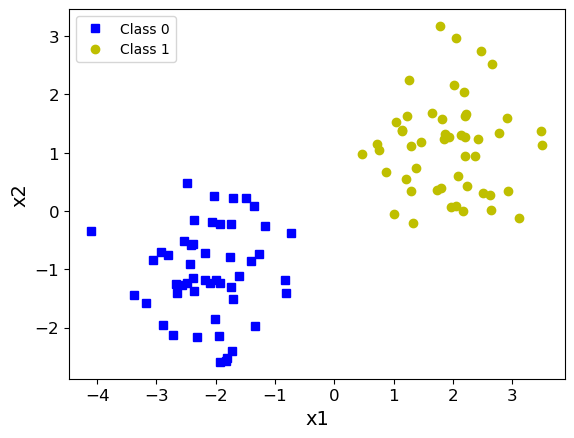

In [4]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

X, y = make_blobs(
    n_samples=100,
    centers=[(-2, -1), (2, 1)],
    cluster_std=0.8,
    random_state=42
)

plt.plot(X[:, 0][y==0], X[:, 1][y==0], "bs", label="Class 0")
plt.plot(X[:, 0][y==1], X[:, 1][y==1], "yo", label="Class 1")
plt.xlabel("x1", fontsize=14)
plt.ylabel("x2", fontsize=14)
plt.legend()
plt.show()

## Problem 1-1. Hard-Margin SVM(Primal form)

qpsolver library를 활용하여 hard-margin SVM의 primal optimization problem을 풀어보세요. <br>
(1)SVM의 primal optimization problem을 Quadratic Programming(QP) 형식에 맞게 변환한 후, 이를 qpsolver에 입력하여 solution을 구하고, <br>
(2)구한 solution을 바탕으로 weight와 bias를 계산하는 코드를 작성하면 됩니다.

QP form의 notation이 강의자료와 다르니, 아래 문서를 참고하시길 바랍니다. <br>
참고(qpsolver): https://pypi.org/project/qpsolvers/

**2개 이상의 LLM을 활용하여 코드를 구현하고, 구현 결과를 비교 분석하여 보고서에 작성하세요.**

In [5]:
import numpy as np
from qpsolvers import solve_qp
from scipy.sparse import csc_matrix

def solve_primal_opt(
    X: np.ndarray,
    y: np.ndarray
    ) -> np.ndarray:
    ################# YOUR CODE COMES HERE ######################
    # Convert labels from {0, 1} to {-1, +1}
    t = y * 2 - 1
    n_samples, n_features = X.shape

    # Decision variable: z = [w (n_features), b (1)]
    # Objective: minimize 0.5 * ||w||^2 = 0.5 * z^T P z + q^T z
    # P is (n_features+1) x (n_features+1), only the w part has identity
    P = np.zeros((n_features + 1, n_features + 1))
    P[:n_features, :n_features] = np.eye(n_features)
    q = np.zeros(n_features + 1)

    # Constraints: t_i * (w^T x_i + b) >= 1  =>  -t_i * (w^T x_i + b) <= -1
    # G z <= h  where G_i = -t_i * [x_i, 1], h_i = -1
    G = np.zeros((n_samples, n_features + 1))
    for i in range(n_samples):
        G[i, :n_features] = -t[i] * X[i]
        G[i, n_features] = -t[i]
    h = -np.ones(n_samples)
    #############################################################

    P = csc_matrix(P) # Convert dense numpy array to sparse CSC matrix for efficient computation
    G = csc_matrix(G) # Convert dense numpy array to sparse CSC matrix for efficient computation

    sol = solve_qp(P, q, G, h, A=None, b=None, solver="osqp")
    return sol

def calculate_weights_from_primal_solution(
    solution: np.ndarray
    ) -> Tuple[np.ndarray, float]:
    ################# YOUR CODE COMES HERE ######################
    # w: coefficient of the model to input features,
    # b: bias of the model
    w = solution[:-1]
    b = solution[-1]
    #############################################################

    return w, b

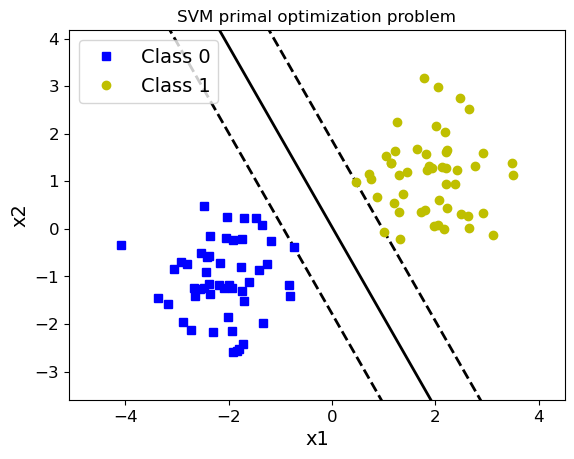

In [6]:
def plot_svc_decision_boundary(w, b, xmin, xmax):
    # At the decision boundary, w0*x0 + w1*x1 + b = 0
    # => x1 = -w0/w1 * x0 - b/w1
    x0 = np.linspace(xmin, xmax, 200)
    decision_boundary = -w[0]/w[1] * x0 - b/w[1]

    margin = 1/w[1]
    gutter_up = decision_boundary + margin
    gutter_down = decision_boundary - margin

    plt.plot(x0, decision_boundary, "k-", linewidth=2)
    plt.plot(x0, gutter_up, "k--", linewidth=2)
    plt.plot(x0, gutter_down, "k--", linewidth=2)

solution = solve_primal_opt(X.copy(),y.copy())
w, b = calculate_weights_from_primal_solution(solution)

x_min, x_max = X[:, 0].min() - 1.0, X[:, 0].max() + 1.0
y_min, y_max = X[:, 1].min() - 1.0, X[:, 1].max() + 1.0

plot_svc_decision_boundary(w, b, x_min, x_max)
plt.plot(X[:, 0][y==0], X[:, 1][y==0], "bs", label="Class 0")
plt.plot(X[:, 0][y==1], X[:, 1][y==1], "yo", label="Class 1")
plt.xlabel("x1", fontsize=14)
plt.ylabel("x2", fontsize=14)
plt.axis([x_min, x_max, y_min, y_max])
plt.legend(loc="upper left", fontsize=14)
plt.title('SVM primal optimization problem')
plt.show()

## Problem 1-2. Hard-Margin SVM(Dual form)

마찬가지로 qpsolver library를 활용하여 hard-margin SVM의 dual optimization problem을 풀어보세요.

**2개 이상의 LLM을 활용하여 코드를 구현하고, 구현 결과를 비교 분석하여 보고서에 작성하세요.**

In [7]:
def solve_dual_opt(
    X: np.ndarray,
    y: np.ndarray
    ) -> np.ndarray:
    ################# YOUR CODE COMES HERE ######################
    # Convert labels from {0, 1} to {-1, +1}
    t = y * 2 - 1
    n_samples = X.shape[0]

    # Dual QP: maximize sum(alpha) - 0.5 * alpha^T H alpha
    # Equivalent to minimize 0.5 * alpha^T H alpha - 1^T alpha
    # where H_ij = t_i * t_j * x_i^T x_j
    H = np.outer(t, t) * (X @ X.T)
    P = H.astype(np.float64)
    q = -np.ones(n_samples)

    # Inequality constraints: alpha_i >= 0  =>  -alpha_i <= 0
    G = -np.eye(n_samples)
    h = np.zeros(n_samples)

    # Equality constraint: sum(alpha_i * t_i) = 0
    A = t.reshape(1, -1).astype(np.float64)
    b = np.zeros(1)
    #############################################################

    P = csc_matrix(P) # Convert dense numpy array to sparse CSC matrix for efficient computation
    G = csc_matrix(G) # Convert dense numpy array to sparse CSC matrix for efficient computation
    A = csc_matrix(A) # Convert dense numpy array to sparse CSC matrix for efficient computation

    sol = solve_qp(P, q, G, h, A, b, solver="osqp")
    return sol

def calculate_weights_from_dual_solution(
    solution: np.ndarray,
    X: np.ndarray,
    y: np.ndarray
    ) -> Tuple[np.ndarray, float]:
    ################# YOUR CODE COMES HERE ######################
    # w: coefficient of the model to input features,
    # b: bias of the model
    t = y * 2 - 1
    alpha = solution
    # w = sum(alpha_i * t_i * x_i)
    w = (alpha * t) @ X
    # Find support vectors (alpha > threshold)
    sv_idx = alpha > 1e-5
    # b = t_s - w^T x_s for any support vector s
    b = np.mean(t[sv_idx] - X[sv_idx] @ w)
    #############################################################
    return w, b

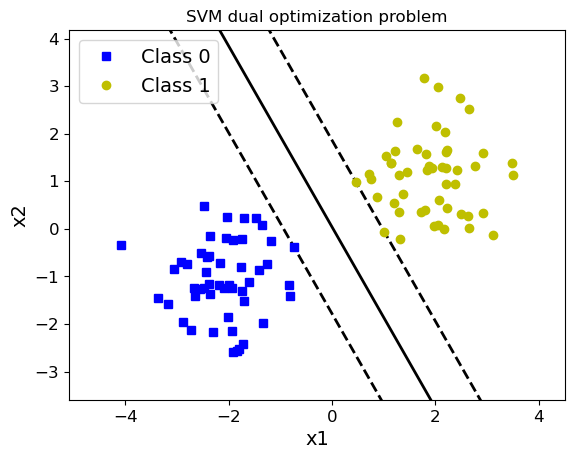

In [8]:
alpha = solve_dual_opt(X.copy(), y.copy())
w, b = calculate_weights_from_dual_solution(alpha, X.copy(), y.copy())

x_min, x_max = X[:, 0].min() - 1.0, X[:, 0].max() + 1.0
y_min, y_max = X[:, 1].min() - 1.0, X[:, 1].max() + 1.0

plot_svc_decision_boundary(w, b, x_min, x_max)
plt.plot(X[:, 0][y==0], X[:, 1][y==0], "bs", label="Class 0")
plt.plot(X[:, 0][y==1], X[:, 1][y==1], "yo", label="Class 1")
plt.xlabel("x1", fontsize=14)
plt.ylabel("x2", fontsize=14)
plt.axis([x_min, x_max, y_min, y_max])
plt.legend(loc="upper left", fontsize=14)
plt.title('SVM dual optimization problem')
plt.show()

## Problem 2. Dataset load & Plot

실행만 시키면 됩니다.

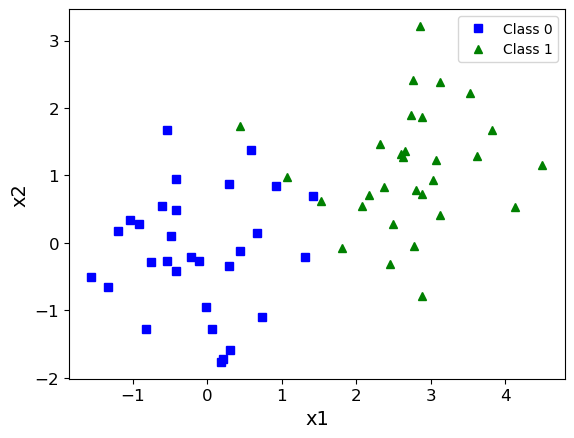

In [9]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

X, y = make_blobs(
    n_samples=60,
    centers=[(0, 0), (2.8, 1.0)],
    cluster_std=0.9,
    random_state=42
)

plt.plot(X[:, 0][y==0], X[:, 1][y==0], "bs", label="Class 0")
plt.plot(X[:, 0][y==1], X[:, 1][y==1], "g^", label="Class 1")
plt.xlabel("x1", fontsize=14)
plt.ylabel("x2", fontsize=14)
plt.legend()
plt.show()

## Problem 2. Soft-Margin SVM


sklearn.svm 의 LinearSVC를 이용하여 soft-margin SVM을 train 시켜보세요. <br>
또한 hyperparameter인 C 값을 바꾸어가며 실험하고, **서로 다른 C값에 대한 plot을 그려 보고서에 첨부하세요. 보고서에는 plot과 함께 결과에 대한 분석을 적어주시면 됩니다.**

참고(LinearSVC):https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html

In [10]:
from sklearn.svm import LinearSVC

def learn_svm_clf(
    X: np.ndarray,
    y: np.ndarray,
    C: float
    ) -> LinearSVC:
    #################### YOUR CODE COMES HERE ####################
    model = LinearSVC(C=C, loss="hinge", max_iter=10000)
    model.fit(X, y)
    ##############################################################
    return model

# hyper parameter(C) 설정, 4개의 값 입력
#################### YOUR CODE COMES HERE ####################
C = [0.01, 0.1, 1, 100]
##############################################################

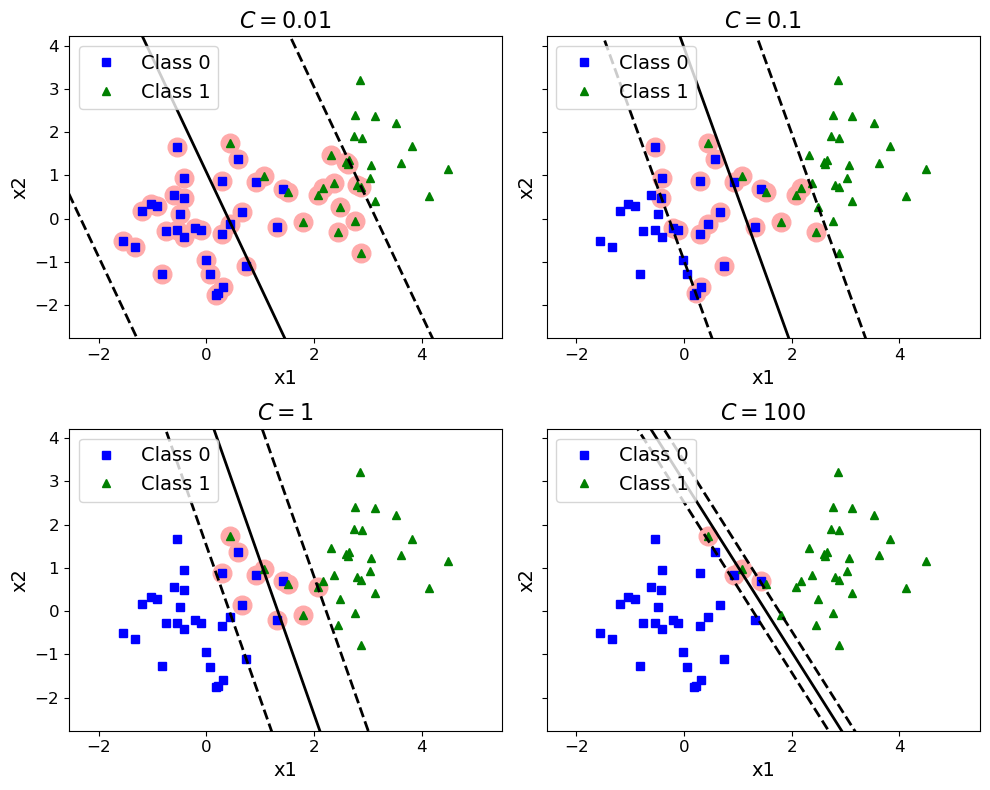

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(10,8), sharey=True)
axes = axes.flatten()

x_min, x_max = X[:, 0].min() - 1.0, X[:, 0].max() + 1.0
y_min, y_max = X[:, 1].min() - 1.0, X[:, 1].max() + 1.0

for i, c in enumerate(C):
    plt.sca(axes[i])

    svm_clf = learn_svm_clf(X, y , c)
    w = svm_clf.coef_[0]
    b = svm_clf.intercept_[0]

    t = y * 2 - 1
    support_vectors_idx = (t * (X.dot(w) + b) < 1).ravel()
    svs = X[support_vectors_idx]

    plt.plot(X[:, 0][y==0], X[:, 1][y==0], "bs", label="Class 0")
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], "g^", label="Class 1")
    plot_svc_decision_boundary(w, b, x_min, x_max)

    plt.scatter(svs[:, 0], svs[:, 1], s=180, facecolors='#FFAAAA')
    plt.xlabel("x1", fontsize=14)
    plt.ylabel("x2", fontsize=14)
    plt.legend(loc="upper left", fontsize=14)
    plt.title("$C = {}$".format(c), fontsize=16)
    plt.axis([x_min, x_max, y_min, y_max])

plt.tight_layout()

########### plot 저장(markdown 보고서에 넣기 위함) ############
os.makedirs('outputs', exist_ok=True)
plt.savefig("outputs/problem_2.png")
#########################################################

plt.show()

## Problem 3. Dataset load & Plot

실행만 시키면 됩니다.

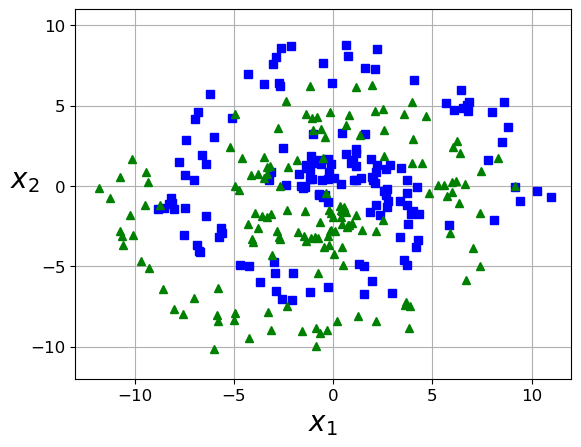

In [12]:
data = np.load('data.npz')
X, X_test, y, y_test = data['X'], data['X_test'], data['y'], data['y_test']

def plot_dataset(X, y, axes):
    plt.plot(X[:, 0][y==0], X[:, 1][y==0], "bs")
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], "g^")
    plt.axis(axes)
    plt.grid(True, which='both')
    plt.xlabel(r"$x_1$", fontsize=20)
    plt.ylabel(r"$x_2$", fontsize=20, rotation=0)

plot_dataset(X, y, [-13, 12, -12, 11])
plt.show()

## Problem 3-1. Non-linear classification(using polynomial kernel)

아래는 polynomial kernel을 이용한 classification의 작동 방식을 시각화한 코드입니다. 코드를 작성할 필요 없이 실행 시킨 뒤 결과를 확인하시면 됩니다.

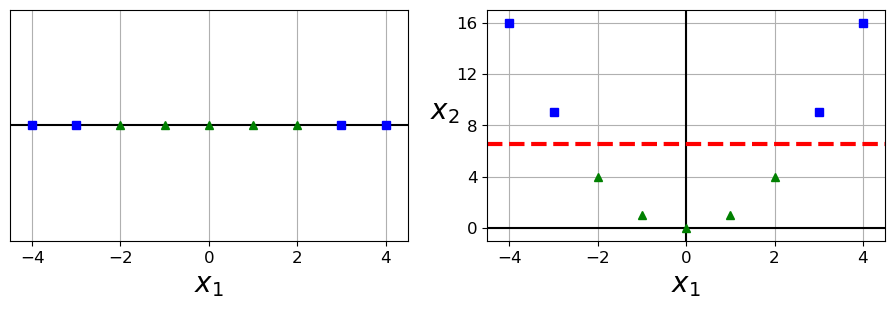

In [13]:
X1D = np.linspace(-4, 4, 9).reshape(-1, 1)
X2D = np.c_[X1D, X1D**2]
yk = np.array([0, 0, 1, 1, 1, 1, 1, 0, 0])

plt.figure(figsize=(10, 3))

plt.subplot(121)
plt.grid(True, which='both')
plt.axhline(y=0, color='k')
plt.plot(X1D[:, 0][yk==0], np.zeros(4), "bs")
plt.plot(X1D[:, 0][yk==1], np.zeros(5), "g^")
plt.gca().get_yaxis().set_ticks([])
plt.xlabel(r"$x_1$", fontsize=20)
plt.axis([-4.5, 4.5, -0.2, 0.2])

plt.subplot(122)
plt.grid(True, which='both')
plt.axhline(y=0, color='k')
plt.axvline(x=0, color='k')
plt.plot(X2D[:, 0][yk==0], X2D[:, 1][yk==0], "bs")
plt.plot(X2D[:, 0][yk==1], X2D[:, 1][yk==1], "g^")
plt.xlabel(r"$x_1$", fontsize=20)
plt.ylabel(r"$x_2$  ", fontsize=20, rotation=0)
plt.gca().get_yaxis().set_ticks([0, 4, 8, 12, 16])
plt.plot([-4.5, 4.5], [6.5, 6.5], "r--", linewidth=3)
plt.axis([-4.5, 4.5, -1, 17])

plt.subplots_adjust(right=1)

plt.show()

sklearn.svm의 SVC를 사용하여 (SVC의 kernel로 polynomial kernel을 사용) non-linear classification model을 train 시켜보세요.<br>
또한 hyperparameter인 degree, coef0, 그리고 C 값을 바꾸어가며 실험하고, **서로 다른 hyperparameter 값에 대한 plot을 그려 보고서에 첨부하세요. 보고서에는 plot과 함께 결과에 대한 분석을 적어주시면 됩니다.**

참고(SVC):https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html <br>
(hyperparameter의 notation이 강의자료와 다를 수 있으니 주의해주세요)

In [14]:
from sklearn.svm import SVC

def learn_poly_kernel_svm_clf(
    X: np.ndarray,
    y: np.ndarray,
    C: float,
    degree: int,
    coef0: float
    ) -> SVC:
    #################### YOUR CODE COMES HERE ####################
    model = SVC(kernel="poly", C=C, degree=degree, coef0=coef0)
    model.fit(X, y)
    ##############################################################
    return model

# hyper parameter(C, degree, coef0) 설정, 각각 2개의 값 입력
#################### YOUR CODE COMES HERE ####################
C = [0.1, 10]
degree = [3, 5]
coef0 = [0, 1]
##############################################################

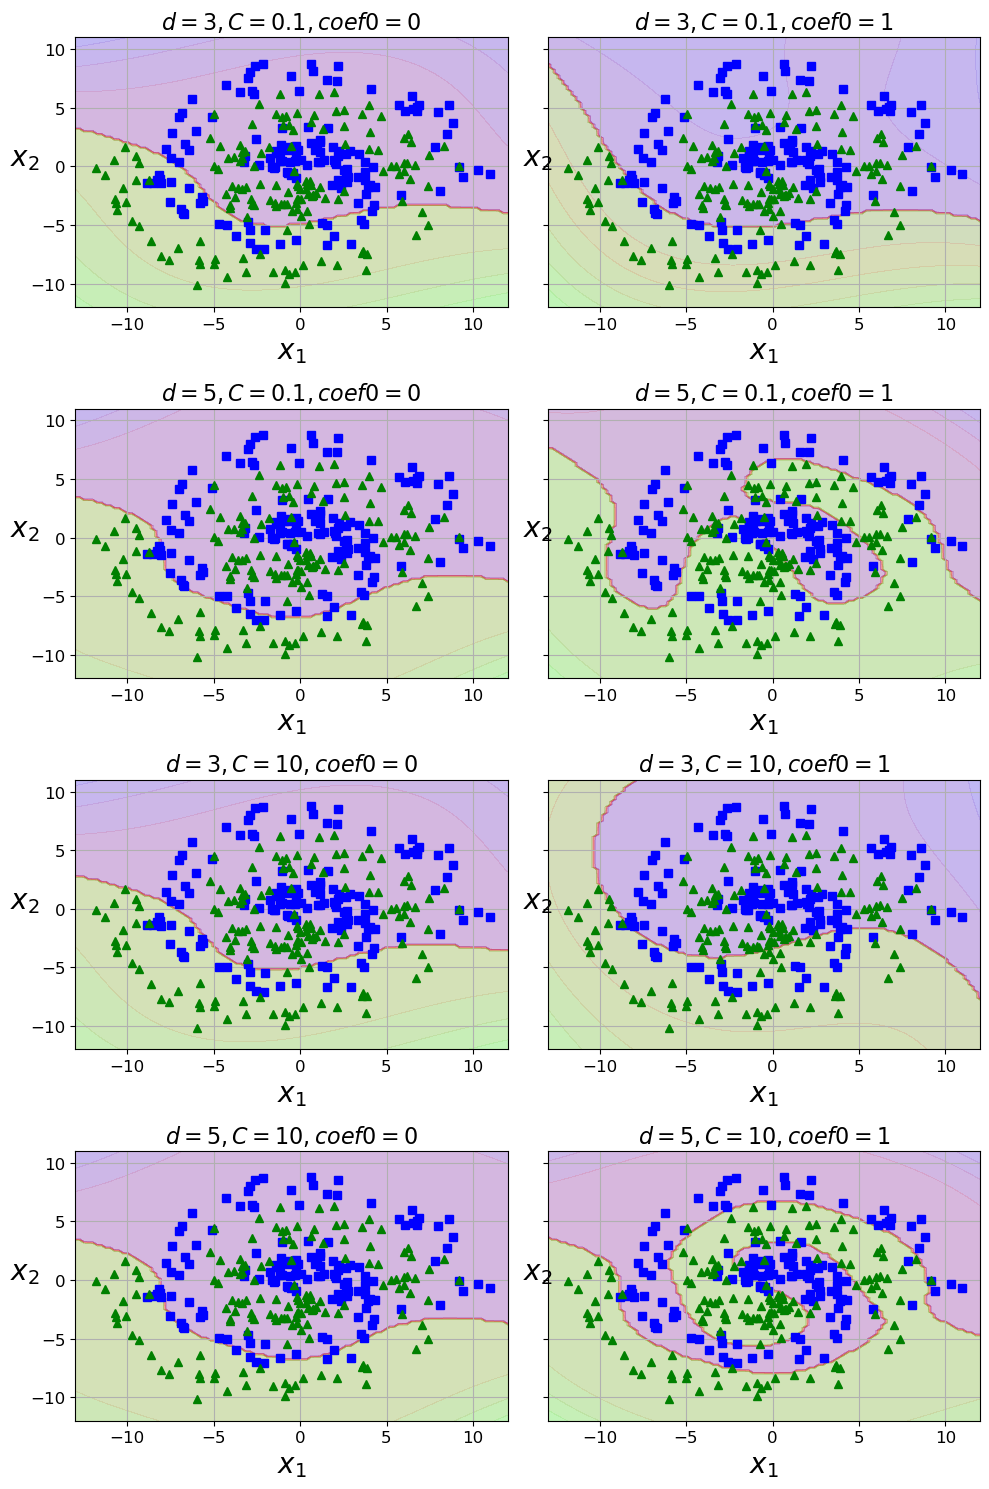

In [15]:
def plot_predictions(clf, axes):
    x0s = np.linspace(axes[0], axes[1], 100)
    x1s = np.linspace(axes[2], axes[3], 100)
    x0, x1 = np.meshgrid(x0s, x1s)
    X = np.c_[x0.ravel(), x1.ravel()]
    y_pred = clf.predict(X).reshape(x0.shape)
    y_decision = clf.decision_function(X).reshape(x0.shape)
    plt.contourf(x0, x1, y_pred, cmap=plt.cm.brg, alpha=0.2)
    plt.contourf(x0, x1, y_decision, cmap=plt.cm.brg, alpha=0.1)

fig, axes = plt.subplots(4, 2, figsize=(10, 15), sharey=True)
axes = axes.flatten()

i = 0
for C_ in C:
    for degree_ in degree:
        for coef0_ in coef0:
            plt.sca(axes[i])
            poly_kernel_svm_clf = learn_poly_kernel_svm_clf(X, y, C_, degree_, coef0_)
            plot_predictions(poly_kernel_svm_clf, [-13, 12, -12, 11])
            plot_dataset(X, y, [-13, 12, -12, 11])
            plt.title("$d={}, C={}, coef0={}$".format(poly_kernel_svm_clf.degree, poly_kernel_svm_clf.C, poly_kernel_svm_clf.coef0, np.mean(poly_kernel_svm_clf.predict(X_test) == y_test)), fontsize=16)
            i += 1

plt.tight_layout()

########### plot 저장(markdown 보고서에 넣기 위함) ############
plt.savefig("outputs/problem_3_1.png")
#########################################################

plt.show()

## Problem 3-2. Non-linear classification(using rbf kernel)

아래는 gaussian rbf kernel을 이용한 classification의 작동 방식을 시각화한 코드입니다. 코드를 작성할 필요 없이 실행 시킨 뒤 결과를 확인하시면 됩니다.

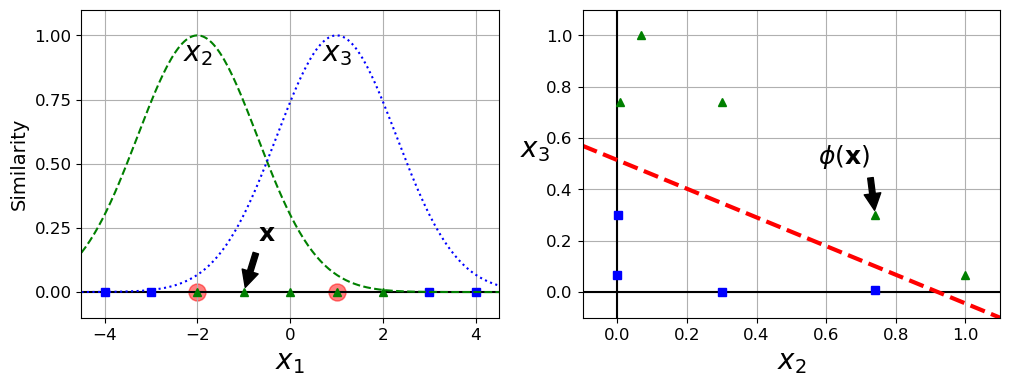

In [16]:
def gaussian_rbf(x, landmark, gamma):
    return np.exp(-gamma * np.linalg.norm(x - landmark, axis=1)**2)

gamma = 0.3

x1s = np.linspace(-4.5, 4.5, 200).reshape(-1, 1)
x2s = gaussian_rbf(x1s, -2, gamma)
x3s = gaussian_rbf(x1s, 1, gamma)

XK = np.c_[gaussian_rbf(X1D, -2, gamma), gaussian_rbf(X1D, 1, gamma)]
yk = np.array([0, 0, 1, 1, 1, 1, 1, 0, 0])

plt.figure(figsize=(10.5, 4))

plt.subplot(121)
plt.grid(True, which='both')
plt.axhline(y=0, color='k')
plt.scatter(x=[-2, 1], y=[0, 0], s=150, alpha=0.5, c="red")
plt.plot(X1D[:, 0][yk==0], np.zeros(4), "bs")
plt.plot(X1D[:, 0][yk==1], np.zeros(5), "g^")
plt.plot(x1s, x2s, "g--")
plt.plot(x1s, x3s, "b:")
plt.gca().get_yaxis().set_ticks([0, 0.25, 0.5, 0.75, 1])
plt.xlabel(r"$x_1$", fontsize=20)
plt.ylabel(r"Similarity", fontsize=14)
plt.annotate(r'$\mathbf{x}$',
             xy=(X1D[3, 0], 0),
             xytext=(-0.5, 0.20),
             ha="center",
             arrowprops=dict(facecolor='black', shrink=0.1),
             fontsize=18,
            )
plt.text(-2, 0.9, "$x_2$", ha="center", fontsize=20)
plt.text(1, 0.9, "$x_3$", ha="center", fontsize=20)
plt.axis([-4.5, 4.5, -0.1, 1.1])

plt.subplot(122)
plt.grid(True, which='both')
plt.axhline(y=0, color='k')
plt.axvline(x=0, color='k')
plt.plot(XK[:, 0][yk==0], XK[:, 1][yk==0], "bs")
plt.plot(XK[:, 0][yk==1], XK[:, 1][yk==1], "g^")
plt.xlabel(r"$x_2$", fontsize=20)
plt.ylabel(r"$x_3$  ", fontsize=20, rotation=0)
plt.annotate(r'$\phi\left(\mathbf{x}\right)$',
             xy=(XK[3, 0], XK[3, 1]),
             xytext=(0.65, 0.50),
             ha="center",
             arrowprops=dict(facecolor='black', shrink=0.1),
             fontsize=18,
            )
plt.plot([-0.1, 1.1], [0.57, -0.1], "r--", linewidth=3)
plt.axis([-0.1, 1.1, -0.1, 1.1])

plt.subplots_adjust(right=1)

plt.show()

sklearn.svm의 SVC를 사용하여 (SVC의 kernel로 rbf kernel을 사용) non-linear classification model을 train 시켜보세요.<br>
또한 hyperparameter인 gamma, 그리고 C 값을 바꾸어가며 실험하고, **서로 다른 hyperparameter 값에 대한 plot을 그려 보고서에 첨부하세요. 보고서에는 plot과 함께 결과에 대한 설명을 적어주시면 됩니다.**

(hyperparameter의 notation이 강의자료와 다를 수 있으니 주의해주세요)

In [17]:
def learn_rbf_kernel_svm_clf(
    X: np.ndarray,
    y: np.ndarray,
    C: float,
    gamma: float
    ) -> SVC:
    #################### YOUR CODE COMES HERE ####################
    model = SVC(kernel="rbf", C=C, gamma=gamma)
    model.fit(X, y)
    ##############################################################
    return model

# hyper parameter(C, gamma) 설정, 각각 2개의 값 입력
#################### YOUR CODE COMES HERE ####################
C = [0.1, 100]
gamma = [0.1, 10]
##############################################################

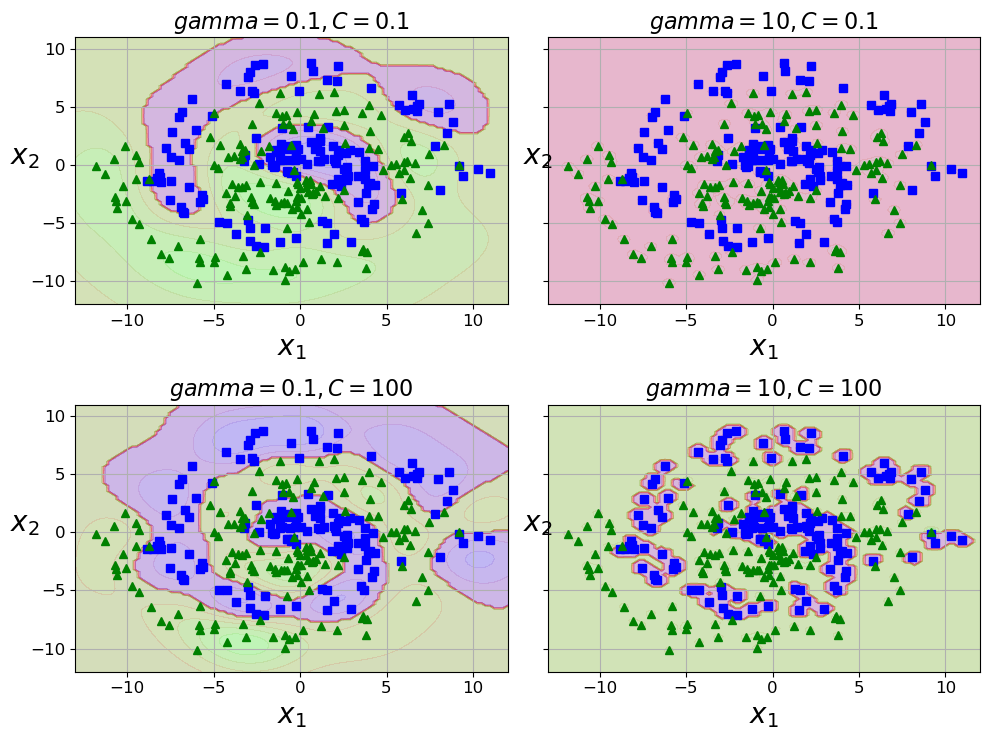

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7.5), sharey=True)
axes = axes.flatten()

i = 0
for C_ in C:
    for gamma_ in gamma:
        plt.sca(axes[i])
        rbf_kernel_svm_clf = learn_rbf_kernel_svm_clf(X, y, C_, gamma_)
        plot_predictions(rbf_kernel_svm_clf, [-13, 12, -12, 11])
        plot_dataset(X, y, [-13, 12, -12, 11])
        plt.title("$gamma={}, C={}$".format(rbf_kernel_svm_clf.gamma, rbf_kernel_svm_clf.C), fontsize=16)
        i += 1

plt.tight_layout()

########### plot 저장(markdown 보고서에 넣기 위함) ############
plt.savefig("outputs/problem_3_2.png")
#########################################################

plt.show()

## Problem 3-3. Non-linear classification(for best accuracy)

수업시간에 배운 kernel, sklearn에서 제공하는 kernel, 직접 만든 kernel 등을 활용하여 최대한 성능을 높여보세요. <br>
필요에 따라 sklearn의 pipeline, scaler 등을 사용해도 괜찮습니다(sklearn 이외의 설치가 추가적으로 필요한 라이브러리를 사용한 경우 불이익이 있을 수 있습니다).<br>
다른 문제와 마찬가지로 YOUR CODE COMES HERE 내부에만 코드를 작성하길 바랍니다. 즉, YOUR CODE COMES HERE 내부에만 코드를 작성하는 경우 sklearn 라이브러리를 불러오는 것, 커널 함수를 정의하여 사용하는 것 등 모두 허용됩니다.<br> 
함수의 입력을 수정해도 되지만, 최종적으로 작성된 함수는 다음처럼 사용할 수 있어야 합니다: ```kernel_svm_clf_best = learn_kernel_svm_clf_best(X, y)```

In [26]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator

def learn_kernel_svm_clf_best(
    X: np.ndarray,
    y: np.ndarray
    ) -> BaseEstimator:
    #################### YOUR CODE COMES HERE ####################
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", C=10, gamma=1))
    ])
    model.fit(X, y)
    ##############################################################
    return model

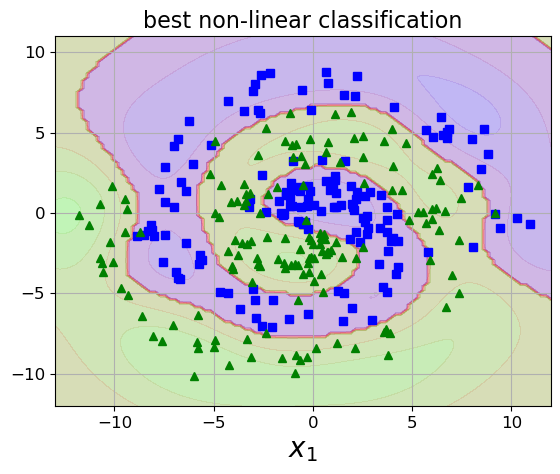

모델 정확도:0.93


In [27]:
kernel_svm_clf_best = learn_kernel_svm_clf_best(X, y)
plot_predictions(kernel_svm_clf_best, [-13, 12, -12, 11])
plot_dataset(X, y, [-13, 12, -12, 11])
plt.title('best non-linear classification', fontsize=16)

plt.ylabel("")

plt.show()


print(f'모델 정확도:{np.mean(kernel_svm_clf_best.predict(X_test) == y_test)}')

Copyright (C) Hands-On Machine Learning with Scikit-Learn and TensorFlow: Concepts, Tools, and Techniques to Build Intelligent Systems. Written by Aurélien Géron.